Import the required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import numpy as np
import seaborn as sns

Load the data

In [2]:
X, y = load_breast_cancer(return_X_y=True)
X.shape

(569, 30)

In [3]:
y.shape

(569,)

Data Splitting & Model Training

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Probabilities of the test set for class 1

In [13]:
# probability only for the class 1
y_prob_lr = model.predict_proba(X_test)[:, 1]
y_prob_lr

array([8.38102207e-01, 3.24417118e-10, 9.70830897e-04, 9.95531599e-01,
       9.99101529e-01, 8.43099570e-11, 6.03662778e-14, 6.32026149e-03,
       9.98629423e-01, 9.82991980e-01, 9.51888426e-01, 2.69188170e-04,
       9.89549327e-01, 1.84827987e-01, 9.97672152e-01, 7.40342322e-04,
       9.96584211e-01, 9.99559536e-01, 9.98405080e-01, 1.68920684e-08,
       7.91211956e-01, 9.84487572e-01, 5.40819482e-11, 9.95350085e-01,
       9.88713396e-01, 9.99372051e-01, 9.96077002e-01, 9.90562286e-01,
       9.93736420e-01, 8.56373055e-10, 9.93800790e-01, 9.98774517e-01,
       9.84631144e-01, 9.70181297e-01, 9.98073905e-01, 9.94999984e-01,
       1.99140001e-03, 9.95709374e-01, 5.85858343e-07, 7.81410480e-01,
       9.97226611e-01, 7.59002399e-04, 9.98231633e-01, 9.86960730e-01,
       9.98398594e-01, 9.51212291e-01, 9.98634967e-01, 9.90067093e-01,
       9.19665950e-01, 9.95305967e-01, 1.66807654e-05, 1.94496072e-10,
       8.71457450e-01, 9.99129552e-01, 9.98195794e-01, 9.72893265e-01,
      

In [8]:
y_pred_lr = model.predict(X_test)
y_pred_lr

array([1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1])

ROC AUC Curve

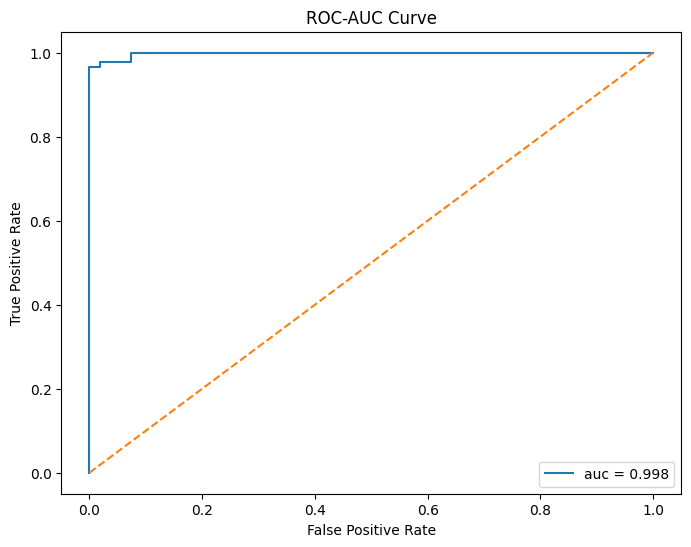

In [7]:
from sklearn.metrics import roc_auc_score, roc_curve

# ROC evaluates the performance of the model across multiple thresholds using probabilities
fpr, tpr, threshold = roc_curve(y_test, y_prob_lr)
auc_score = roc_auc_score(y_test, y_prob_lr)

# plot roc-auc curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'auc = {auc_score:.3f}')

# random model line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curve')
plt.legend()
plt.show()

In [9]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred_lr)
cm

array([[51,  3],
       [ 2, 87]])

In [10]:
tn, fp, fn, tp = cm.ravel()
print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)
print("True Positives (TP):", tp)

True Negatives (TN): 51
False Positives (FP): 3
False Negatives (FN): 2
True Positives (TP): 87


Visualize the confusion matrix

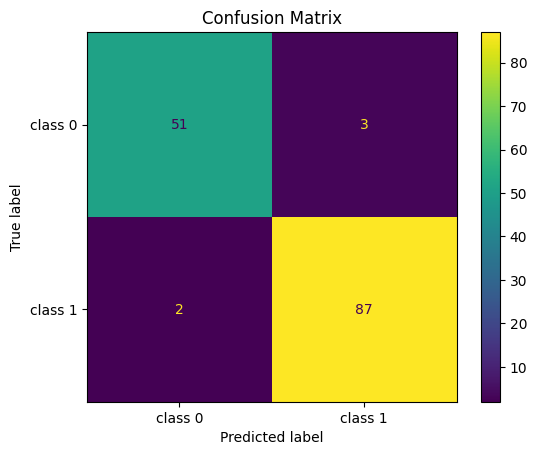

In [11]:
from sklearn.metrics import ConfusionMatrixDisplay

display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['class 0', 'class 1'])
display.plot()
plt.title('Confusion Matrix')
plt.show()

Impact of different threshold on Confusion Matrix

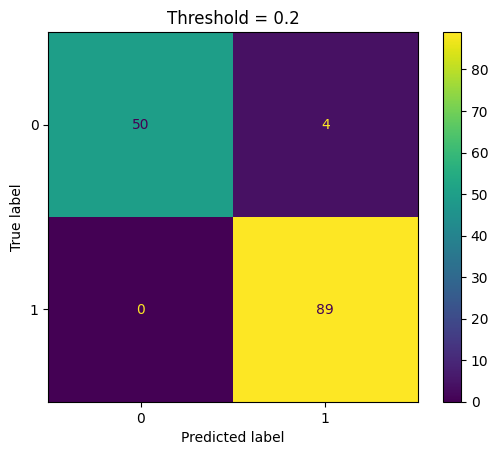

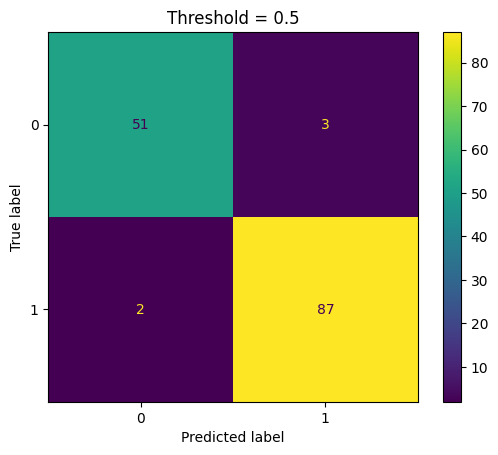

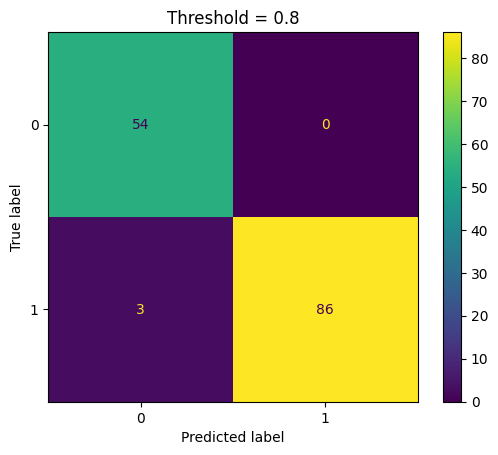

In [15]:
thresholds = [0.2, 0.5, 0.8]
# 0.2 => recall increases because FN values are 0
# 0.8 => precision increases because FP values are 0
y_prob = model.predict_proba(X_test)[:,1]

for threshold in thresholds:
  y_pred = (y_prob >= threshold).astype(int)
  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

  disp.plot()
  plt.title(f"Threshold = {threshold}")
  plt.show()